<a href="https://colab.research.google.com/github/nissi31/projects/blob/main/image_correspondence_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Image Correspondence using Deep Learning Technique



##Using SuperGlue
This method utilizes the match_pairs.py script included in the official SuperGlue repository

mkdir: cannot create directory ‘my_images’: File exists
--2025-07-11 17:25:44--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50728 (50K) [image/png]
Saving to: ‘my_images/box.png’

my_images/box.png   100%[===================>]  49.54K  --.-KB/s    in 0.007s  

2025-07-11 17:25:44 (7.29 MB/s) - ‘my_images/box.png’ saved [50728/50728]

--2025-07-11 17:25:44--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sen

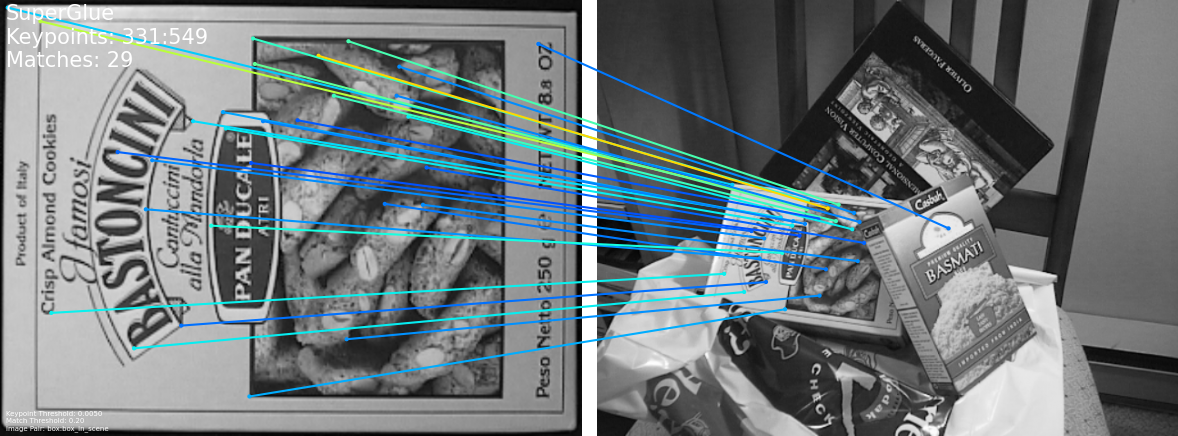

In [ ]:

# placed them in a new directory called 'my_images'
!mkdir my_images
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png -O my_images/box.png
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png -O my_images/box_in_scene.png

print("Images downloaded successfully into 'my_images/' directory.")

!git clone https://github.com/magicleap/SuperGluePretrainedNetwork.git
%cd SuperGluePretrainedNetwork

# The match_pairs.py script needs a text file that lists which images to compare.
with open('my_pairs.txt', 'w') as f:
  f.write('box.png box_in_scene.png\n')

# --input_dir: The folder containing my images.
# --input_pairs: The text file defining the image pair.
# --output_dir: Where to save the result.
# --viz: A flag to create and save a visualization of the matches.
!python match_pairs.py \
  --input_dir my_images/ \
  --input_pairs my_pairs.txt \
  --output_dir my_output/ \
  --viz

from IPython.display import Image, display
import os

output_image_path = os.path.join('my_output', 'box_box_in_scene_matches.png')

if os.path.exists(output_image_path):
  print("\nDisplaying the result:")
  display(Image(filename=output_image_path))
else:
  print("\nCould not find the output image. Please check the logs above for errors.")

In [ ]:

# !pip uninstall -y torch torchvision torchaudio numpy opencv-python matplotlib

# !pip install torch torchvision
# !pip install numpy
# !pip install opencv-python
# !pip install matplotlib

import torch
import cv2
import numpy as np
import matplotlib

PyTorch version: 2.7.1+cu126
OpenCV version: 4.12.0
NumPy version: 2.2.6
Matplotlib version: 3.10.3


In [ ]:
!mkdir -p my_images

!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png -O my_images/box.png
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png -O my_images/box_in_scene.png

!git clone https://github.com/magicleap/SuperGluePretrainedNetwork.git
%cd SuperGluePretrainedNetwork

import os
img1_path = 'my_images/box.png'
img2_path = 'my_images/box_in_scene.png'

--2025-07-11 17:10:52--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50728 (50K) [image/png]
Saving to: ‘my_images/box.png’

my_images/box.png   100%[===================>]  49.54K  --.-KB/s    in 0.007s  

2025-07-11 17:10:52 (6.56 MB/s) - ‘my_images/box.png’ saved [50728/50728]

--2025-07-11 17:10:52--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122490 (120K) [im

In [ ]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from models.matching import Matching
from models.utils import (frame2tensor, make_matching_plot_fast)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

config = {
    'superpoint': {
        'nms_radius': 4,
        'keypoint_threshold': 0.005,
        'max_keypoints': 1024
    },
    'superglue': {
        'weights': 'outdoor',
        'sinkhorn_iterations': 20,
        'match_threshold': 0.2,
    }
}
matching = Matching(config).eval().to(device)

Using device: cpu
Loaded SuperPoint model
Loaded SuperGlue model ("outdoor" weights)


In [ ]:
def load_image(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Failed to load image: {image_path}")
    image = cv2.resize(image, (640, 480))
    tensor = frame2tensor(image, device)
    return image, tensor

img1_path = 'my_images/box.png'
img2_path = 'my_images/box_in_scene.png'
img1, tensor1 = load_image(img1_path)
img2, tensor2 = load_image(img2_path)

pred = matching({'image0': tensor1, 'image1': tensor2})
kpts0 = pred['keypoints0'][0].cpu().numpy()
kpts1 = pred['keypoints1'][0].cpu().numpy()
matches = pred['matches0'][0].cpu().numpy()
conf = pred['matching_scores0'][0].detach().cpu().numpy()

valid = matches > -1
mkpts0 = kpts0[valid]
mkpts1 = kpts1[matches[valid]]
mconf = conf[valid]

if len(mkpts0) >= 4:
    H, mask = cv2.findHomography(mkpts0, mkpts1, cv2.RANSAC, 5.0)
    print("Homography Matrix:\n", H)
else:
    print("Not enough matches for homography estimation.")
    H, mask = None, None

Homography Matrix:
 [[ 2.84857381e-01 -9.58375104e-02  1.47470880e+02]
 [ 6.61265978e-03  2.28558688e-01  2.01444836e+02]
 [-1.04989755e-04 -1.79841794e-04  1.00000000e+00]]


=== SuperGlue Matching Results ===
Image 1 (box.png) Keypoints: 331
Image 2 (box_in_scene.png) Keypoints: 549
Number of Matches: 68
Homography Matrix:
[[ 2.84857381e-01 -9.58375104e-02  1.47470880e+02]
 [ 6.61265978e-03  2.28558688e-01  2.01444836e+02]
 [-1.04989755e-04 -1.79841794e-04  1.00000000e+00]]

Output saved to: /content/matches_output.png


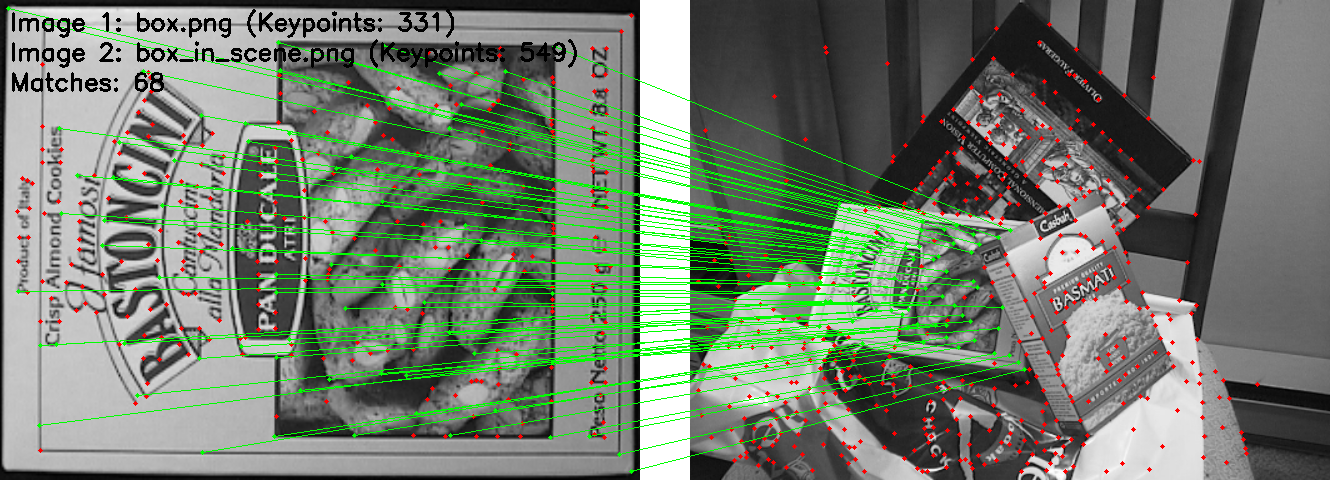

In [ ]:
from IPython.display import Image, display

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)

match_color = (0, 255, 0)
keypoint_color = (0, 0, 255)

num_matches = len(mkpts0)
num_kpts0 = len(kpts0)
num_kpts1 = len(kpts1)
text = [
    f"Image 1: box.png (Keypoints: {num_kpts0})",
    f"Image 2: box_in_scene.png (Keypoints: {num_kpts1})",
    f"Matches: {num_matches}"
]

def make_matching_plot_custom(image0, image1, kpts0, kpts1, mkpts0, mkpts1, match_color, keypoint_color, text, margin=10):
    H0, W0, _ = image0.shape
    H1, W1, _ = image1.shape
    H, W = max(H0, H1), W0 + W1 + margin

    out = np.ones((H, W, 3), dtype=np.uint8) * 255
    out[:H0, :W0] = image0
    out[:H1, W0 + margin:] = image1

    for pt in kpts0:
        x, y = map(int, pt)
        cv2.circle(out, (x, y), 2, keypoint_color, -1)
    for pt in kpts1:
        x, y = map(int, pt)
        cv2.circle(out, (x + W0 + margin, y), 2, keypoint_color, -1)

    for pt0, pt1 in zip(mkpts0, mkpts1):
        x0, y0 = map(int, pt0)
        x1, y1 = map(int, pt1)
        cv2.line(out, (x0, y0), (x1 + W0 + margin, y1), match_color, 1)
        cv2.circle(out, (x0, y0), 2, match_color, -1)
        cv2.circle(out, (x1 + W0 + margin, y1), 2, match_color, -1)

    for i, line in enumerate(text):
        cv2.putText(out, line, (10, 30 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)  # Black text

    return out

out = make_matching_plot_custom(
    img1_rgb, img2_rgb, kpts0, kpts1, mkpts0, mkpts1, match_color, keypoint_color, text, margin=50
)

print("SuperGlue Matching")
print(f"Image 1 (box.png) Keypoints: {num_kpts0}")
print(f"Image 2 (box_in_scene.png) Keypoints: {num_kpts1}")
print(f"Number of Matches: {num_matches}")
if 'H' in locals():
    print(f"Homography Matrix:\n{H}")

plt.figure(figsize=(14, 8))
plt.imshow(out)
plt.axis('off')
plt.title('SuperGlue Keypoint Matches: box.png vs box_in_scene.png')
plt.show()

output_path = '/content/matches_output.png'
cv2.imwrite(output_path, out)
print(f"\nOutput saved to: {output_path}")
display(Image(filename=output_path))